# Essay crops — augmented (as in training) vs clean

**Re-run the last cell** to resample random lines (no fixed seed). For each line: top = augmented *exactly* as training feeds it (frame jitter + photometric at `aug_prob`), below = the clean labelled box.

> Uses the training deps (omegaconf / torchvision) — run where they're installed.

In [1]:
import random, sys
from pathlib import Path

import matplotlib.pyplot as plt
from omegaconf import OmegaConf

# find the recognition/ root (holds src/ and finetune_essays/)
here = Path.cwd()
ROOT = here if (here / "src").exists() else here.parent
sys.path.insert(0, str(ROOT))

from finetune_essays.dataset import parse_labels, EssayLineDataset
from finetune_essays.augment import EssayAugmenter

cfg = OmegaConf.load(ROOT / "finetune_essays/config.yaml")
data_root = Path(cfg.data_root)
records = parse_labels(data_root / cfg.get("labels", "labels.txt"), data_root)
jpos, jneg = cfg.get("jitter_pos", 0.02), cfg.get("jitter_neg", 0.02)
mf = cfg.get("margin_frac", 0.06)

# exactly what training feeds the model: frame jitter + photometric at aug_prob
train_ds = EssayLineDataset(records, EssayAugmenter(train=True, p=cfg.get("aug_prob", 0.7)),
                            train=True, jitter_pos=jpos, jitter_neg=jneg, margin_frac=mf)
# the clean labelled box (no jitter, no photometric)
clean_ds = EssayLineDataset(records, augment=None, train=False,
                            jitter_pos=jpos, jitter_neg=jneg, margin_frac=mf)
print(f"{len(records)} lines ready")


def show(rows, titles, w=14):
    n = len(rows)
    fig, axes = plt.subplots(n, 1, figsize=(w, 0.9 * n + 0.4))
    if n == 1:
        axes = [axes]
    for ax, im, t in zip(axes, rows, titles):
        ax.imshow(im); ax.set_title(t, fontsize=9, loc="left"); ax.axis("off")
    plt.tight_layout(); plt.show()

1666 lines ready


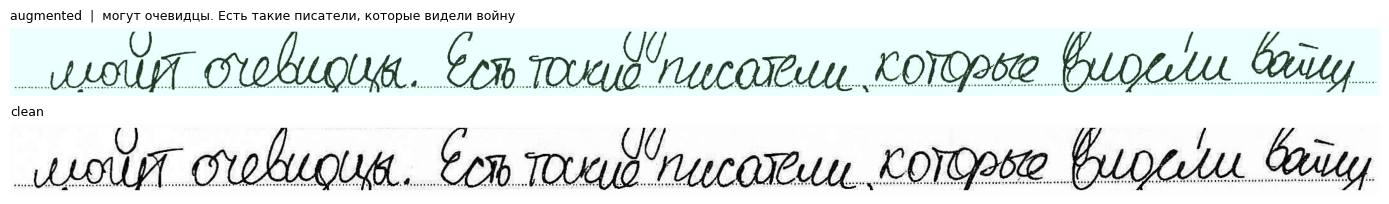

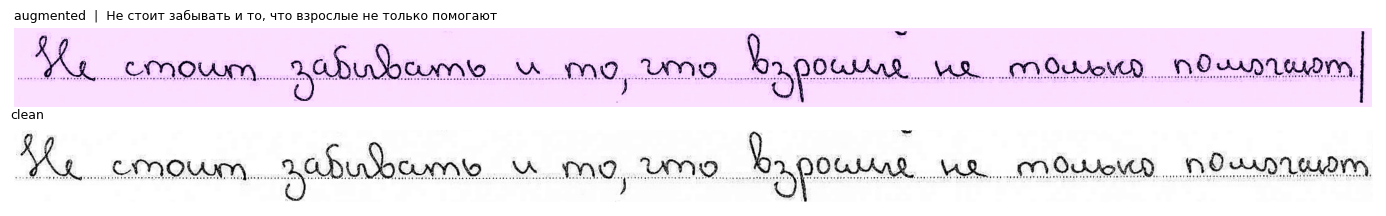

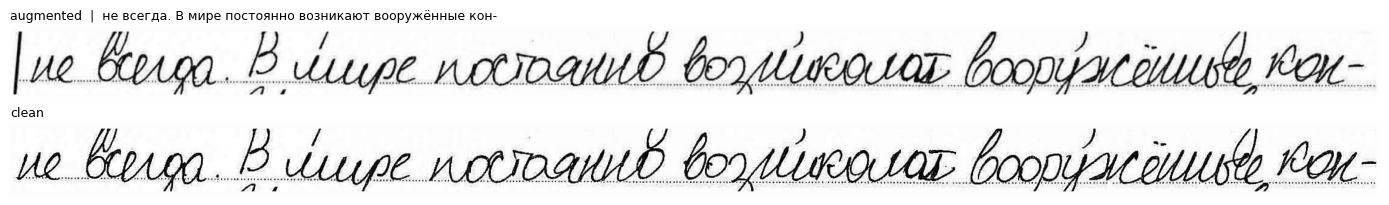

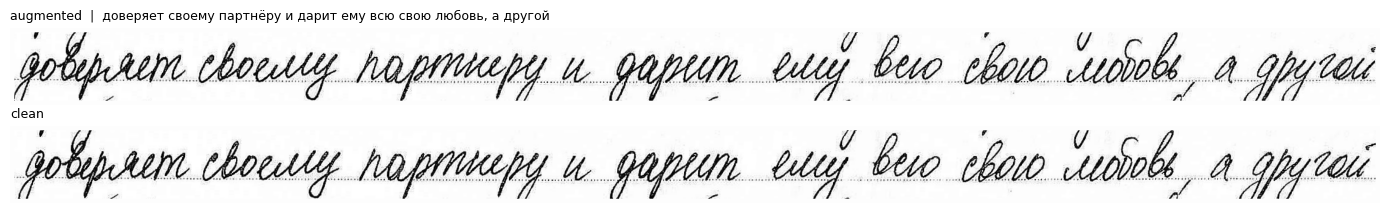

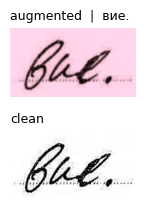

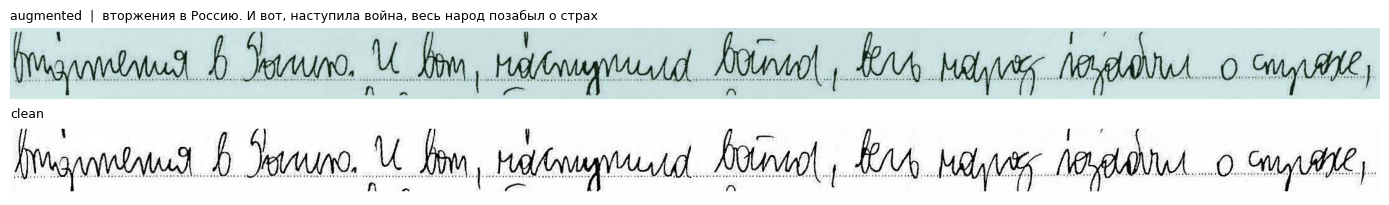

In [3]:
# RE-RUN this cell to resample random lines. Top = augmented (as in training), below = clean.
n_lines = 6
for i in random.sample(range(len(records)), n_lines):
    a, c = train_ds[i], clean_ds[i]
    show([a["image"], c["image"]], [f"augmented  |  {a['text'][:70]}", "clean"])